## Постановка задачи

Решаем нелинейное уравнение  вида
$$
f(x)=0,\qquad f:[a,b]\to\mathbb R.
$$

Предполагается, что известен отрезок $[a,b]$, на котором есть корень или хотя бы смена знака функции $f(a) \cdot f(b)$.

Корень $\alpha$ называется простым, если $f(\alpha)=0,\ f'(\alpha)\ne 0$.  
Рассматриваются итерационные методы приближенного вычисления корня, для которых критерии остановки обычно комбинируют:
$$
|x_{k+1}-x_k|\le \varepsilon_x,\qquad |f(x_k)|\le \varepsilon_f.
$$

## 1. Метод простых итераций

Уравнение $f(x)=0$ приводится к виду
$$
x=\varphi(x).
$$
Тогда строится последовательность
$$
x_{k+1}=\varphi(x_k).
$$

### Алгоритм
1. Привести $f(x)=0$ к $x=\varphi(x)$.
2. Выбрать $x_0\in[a,b]$.
3. Для $k=0,1,2,\dots$ вычислять $x_{k+1}=\varphi(x_k)$.
4. Остановиться при $|x_{k+1}-x_k|\le \varepsilon$.

### Математическое обоснование
Если $\varphi$ непрерывна на $[a,b]$, отображает $[a,b]$ в себя и является **сжимающим**:
$$
|\varphi(x)-\varphi(y)|\le q|x-y|,\qquad 0\le q<1,
$$
то существует единственная неподвижная точка $\alpha\in[a,b]$, и при любом $x_0\in[a,b]$
$$
x_k\to \alpha.
$$
Если $\varphi\in C^1[a,b]$, достаточно проверить
$$
|\varphi'(x)|\le q<1\quad \forall x\in[a,b].
$$

*Если $q$ близко к 1, сходимость очень медленная.*

Для $f(x)=0$ можно построить $\varphi(x)=x-\tau f(x)$; тогда нужно подбирать $\tau$, чтобы $|\varphi'|<1$.

Оценки погрешности:
$$
|x_k-\alpha|\le q^k |x_0-\alpha|,
$$
$$
|x_k-\alpha|\le \frac{q^k}{1-q}|x_1-x_0|,
$$
$$
|x_k-\alpha|\le \frac{q}{1-q}|x_k-x_{k-1}|.
$$

### Пример
$$
f(x)=x^3-x-2=0.
$$
Тогда
$$
x^3=x+2,\qquad x=\sqrt[3]{x+2}=\varphi(x).
$$
На отрезке $[1,2]$
$$
\varphi'(x)=\frac{1}{3(x+2)^{2/3}},\qquad 
\max_{[1,2]}|\varphi'|\approx 0{,}16<1.
$$
Значит, метод сходится. Итерации:
$$
x_0=1{,}5,\quad
x_1=\sqrt[3]{3{,}5}\approx1{,}518,\quad
x_2\approx1{,}521,\quad \alpha\approx1{,}5213797.
$$


In [4]:
def simple_iteration(phi, x0, tol=1e-12, maxiter=1000):
    x = x0
    for k in range(maxiter):
        x_new = phi(x)
        if abs(x_new - x) < tol:
            return x_new, k + 1
        x = x_new        
    return x, maxiter

def f(x: float) -> float:
    return x ** 3 - x - 2

def phi1(x: float) -> float:
    return x - 0.1 * f(x)

def phi2(x: float) -> float:
    return (x + 2) ** (1 / 3)

simple_iteration(phi1, 2), simple_iteration(phi2, 2)

((1.5213797068048602, 30), (1.5213797068046757, 15))

## 2. Бинарный поиск / метод бисекции

Если $f$ непрерывна и $f(a)f(b)<0$, то на $(a,b)$ есть корень. Отрезок делят пополам и оставляют ту половину, где знак меняется.

### Алгоритм
Дано: $f,\ a,\ b,\ \varepsilon$.  
Если $f(a)f(b)>0$, корень не локализован.

Пока $b-a>\varepsilon$:
$$
c=\frac{a+b}{2}.
$$
Если $f(c)=0$, вернуть $c$.  
Если $f(a)f(c)<0$, то $b=c$, иначе $a=c$.  
В конце вернуть $(a+b)/2$.

### Математическое обоснование
Строятся вложенные отрезки:
$$
[a_0,b_0]\supset[a_1,b_1]\supset\cdots,
$$
причём
$$
b_k-a_k=\frac{b-a}{2^k}.
$$
Последовательности $a_k$ и $b_k$ сходятся к общей точке $\alpha$. По непрерывности $f$ и сохранению смены знака получаем $f(\alpha)=0$.  
Оценка погрешности:
$$
|x_k-\alpha|\le \frac{b-a}{2^{k+1}}.
$$

### Пример
$$
f(x)=x^3-x-2,\qquad [1,2].
$$
$f(1)=-2<0,\ f(2)=4>0$.  
Итерации:
$$
c_1=1{,}5,\ f(c_1)<0\Rightarrow a=1{,}5;
$$
$$
c_2=1{,}75,\ f(c_2)>0\Rightarrow b=1{,}75;
$$
$$
c_3=1{,}625,\ f(c_3)>0\Rightarrow b=1{,}625;
$$
и так далее. Корень $\alpha\approx1{,}5213797$.

In [5]:
def bisection(f, a, b, tol=1e-12, maxiter=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) и f(b) должны иметь разные знаки")
    c = 0.5 * (a + b)
    for k in range(maxiter):
        c = 0.5 * (a + b)
        fc = f(c)
        if fc == 0.0 or (b - a) * 0.5 < tol:
            return c, k + 1
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, maxiter

bisection(f, 1, 2)

(1.5213797068054191, 40)

## 3. Метод хорд

Метод хорд - это метод, при котором корень приближается точкой пересечения хорды с осью $Ox$.

### Алгоритм
Дано: $f(a)f(b)<0$.

Для текущих $a,b$:
$$
x=a-\frac{f(a)(b-a)}{f(b)-f(a)}
=\frac{a f(b)-b f(a)}{f(b)-f(a)}.
$$
Если $f(a)f(x)<0$, положить $b=x$, иначе $a=x$.  
Повторять до $|f(x)|<\varepsilon$ или $|b-a|<\varepsilon$.

### Математическое обоснование
Хорда — это линейная интерполяция $f$ по точкам $a,b$. Её корень даёт $x$.  
Если $f\in C^2[a,b]$, то
$$
f(x)=f''(\xi)\frac{(x-a)(x-b)}{2}
$$
в точке пересечения хорды с осью. Можно оценить знак $f(x)$ и конец отрезка, который нужно заменить.  

Если $f$ строго выпукла или строго вогнута на $[a,b]$, $f''$ не меняет знак и $f'\ne0$, то метод сходится к единственному корню. Скорость линейная.

In [ ]:
def chord(f, a, b, tol=1e-12, maxiter=200):    
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("f(a) и f(b) должны иметь разные знаки")
    x = a
    for k in range(maxiter):
        x = (a * fb - b * fa) / (fb - fa)
        fx = f(x)
        if abs(fx) < tol or abs(b - a) < tol:
            return x, k + 1
        if fa * fx < 0:
            b, fb = x, fx
        else:
            a, fa = x, fx
    return x, maxiter

chord(f, 1, 2)

(1.521379706804485, 24)



### 3.1 Метод секущих
Часто под «методом хорд» понимают метод секущих, когда
$$
x_{k+1}=x_k-\frac{f(x_k)(x_k-x_{k-1})}{f(x_k)-f(x_{k-1})}.
$$
Требует двух начальных точек и при хорошем начальном приближении (достаточно близком к корню), $f\in C^2$, $f'(\alpha)\ne0$ имеет сверхлинейную сходимость порядка
$$
p=\frac{1+\sqrt5}{2}\approx1{,}618.
$$

Для гарантированной сходимости требуется исследовать условия: $f\in C^2$, $f'$ и $f''$ не меняют знак на отрезке.

### Пример
$$
f(x)=x^3-x-2,\quad [1,2].
$$
Первая хорда:
$$
x_1=1-\frac{(-2)(2-1)}{4-(-2)}=1+\frac{2}{6}=1{,}3333.
$$
Так как $f(1)<0,\ f(1{,}3333)<0$, заменяем $a=1{,}3333$. Следующая хорда даёт $x_2\approx1{,}4627$, затем $x_3\approx1{,}5040$ и т.д.


In [12]:
def secant(f, x0, x1, tol=1e-12, maxiter=100):    
    f0, f1 = f(x0), f(x1)
    for k in range(maxiter):        
        if f1 == f0:
            return x1, k
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        if abs(x2 - x1) < tol:
            return x2, k + 1
        x0, f0 = x1, f1
        x1, f1 = x2, f(x2)
    return x1, maxiter

secant(f, 1, 2)

(1.5213797068045676, 8)

## 4. Метод касательных / метод Ньютона

В точке $x_k$ функция заменяется касательной:
$$
f(x)\approx f(x_k)+f'(x_k)(x-x_k).
$$
Её корень даёт следующее приближение $x_{k+1}$.

### Алгоритм
Дано: $f,\ f',\ x_0,\ \varepsilon$.

Для $k=0,1,2,\dots$:
$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$
Остановка при $|x_{k+1}-x_k|\le\varepsilon$ или $|f(x_k)|\le\varepsilon_f$.

### Математическое обоснование
Если $f\in C^2$ в окрестности простого корня $\alpha$, $f(\alpha)=0$, $f'(\alpha)\ne0$, то существует $\delta>0$, такое что при $x_0\in(\alpha-\delta,\alpha+\delta)$ метод сходится, причём квадратично:
$$
x_{k+1}-\alpha
=
\frac{f''(\xi_k)}{2 f'(x_k)}(x_k-\alpha)^2.
$$
Следовательно,
$$
|x_{k+1}-\alpha|\le C |x_k-\alpha|^2,
$$
где
$$
C\approx \frac{|f''(\alpha)|}{2|f'(\alpha)|}.
$$
Это означает, что число верных знаков примерно удваивается на каждой итерации.

### Глобальная теорема Фурье
Если $f\in C^2[a,b]$, $f(a)f(b)<0$, $f'$ и $f''$ не меняют знак на $[a,b]$, то корень единственен. Если выбрать $x_0$ так, что
$$
f(x_0)f''(x_0)>0,
$$
то метод Ньютона сходится монотонно.

Метод может расходиться, зацикливаться, уходить далеко, если $f'$ мала или начальное приближение плохое.

Поэтому на практике часто используют демпфирование:
  $$
  x_{k+1}=x_k-\lambda_k \frac{f(x_k)}{f'(x_k)},\qquad 0<\lambda_k\le1,
  $$
  выбирая $\lambda_k$ так, чтобы уменьшалась $|f|$ или норма невязки.

### Пример
$$
f(x)=x^3-x-2,\qquad f'(x)=3x^2-1.
$$
Возьмём $x_0=1{,}5$:
$$
x_1=1{,}5-\frac{-0{,}125}{5{,}75}\approx1{,}521739,
$$
$$
x_2\approx1{,}521386,\qquad \alpha\approx1{,}5213797.
$$
Сходимость очень быстрая.

In [17]:
def newton(f, df, x0, tol=1e-12, maxiter=100):
    x = x0
    for k in range(maxiter):
        fx = f(x)
        dfx = df(x)
        if dfx == 0.0:
            raise ZeroDivisionError("f'(x) = 0")
        dx = fx / dfx
        x -= dx
        if abs(dx) < tol:
            return x, k + 1
    return x, maxiter

def df(x: float):
    return 3 * x ** 2 - 1

newton(f, df, 2)

(1.5213797068045676, 6)

In [15]:
f.__name__

'f'

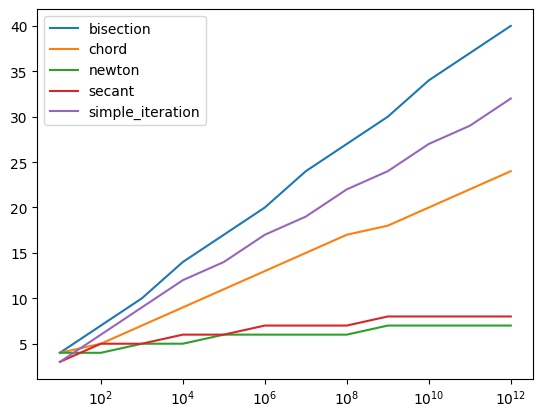

In [27]:
eps = [10 ** (-p) for p in range(1, 13)]
methods = [simple_iteration, bisection, chord, secant, newton]
params = [(phi1, 1), (f, 1, 2), (f, 1, 2), (f, 1, 2), (f, df, 1) ]

import pandas as pd
res = {'tol':[], 'method': [], 'iter': []}
for e in eps:
    for method, param in zip(methods, params):
        root, iter = method(*param, e)
        res['tol'] += [e]
        res['method'] += [method.__name__]
        res['iter'] += [iter]
res_df = pd.DataFrame(res)
methods_df = res_df.groupby('method')

import matplotlib.pyplot as plt

ax = plt.subplot()
for name, data in methods_df:
    #print(data)
    ax.plot(1 / data['tol'], data['iter'], label=name)
ax.set_xscale('log')
ax.legend()


## 5. Решение систем нелинейных уравнений

Дана система
$$
F(x)=0,\qquad F:\mathbb R^n\to\mathbb R^n,
$$
$$
F(x)=
\begin{pmatrix}
f_1(x_1,\dots,x_n)\\
\vdots\\
f_n(x_1,\dots,x_n)
\end{pmatrix}=0.
$$
Матрица Якоби:
$$
J(x)=F'(x)=\left(\frac{\partial f_i}{\partial x_j}\right)_{i,j=1}^n.
$$

### 5.1. Метод Ньютона для систем

Алгоритм:
1. Выбрать $x^{(0)}$.
2. Для $k=0,1,2,\dots$:
   $$
   J(x^{(k)})\Delta x^{(k)}=-F(x^{(k)}).
   $$
3. Решить линейную систему относительно $\Delta x^{(k)}$.
4. Положить
   $$
   x^{(k+1)}=x^{(k)}+\Delta x^{(k)}.
   $$
5. Остановиться при $\|\Delta x^{(k)}\|\le\varepsilon$ или $\|F(x^{(k)})\|\le\varepsilon$.

Обоснование: разложение Тейлора
$$
F(x^{(k)}+\Delta)=F(x^{(k)})+J(x^{(k)})\Delta+O(\|\Delta\|^2).
$$
Отбрасывая квадратичный член, получаем линейную систему.

Если $F\in C^2$ в окрестности решения $\alpha$, $J(\alpha)$ невырождена, то при достаточно близком $x^{(0)}$ метод сходится квадратично:
$$
\|x^{(k+1)}-\alpha\|\le C\|x^{(k)}-\alpha\|^2.
$$

**Требования и ограничения:**
- для метода нужно знать матрицу Якоби;
- $J(\alpha)$ должна быть невырождена;
- нужно хорошее начальное приближение;
- на каждой итерации надо решать линейную систему $n\times n$

### 5.2. Простые итерации для систем

Систему приводят к виду
$$
x=G(x).
$$
Тогда
$$
x^{(k+1)}=G(x^{(k)}).
$$
Если $G$ — сжатие в норме:
$$
\|G(x)-G(y)\|\le q\|x-y\|,\qquad q<1,
$$
то последовательность сходится к единственной неподвижной точке. Если $G\in C^1$, достаточно
$$
\|G'(x)\|\le q<1
$$
в рабочей области.

Часто берут
$$
G(x)=x-A F(x),
$$
где $A$ — некоторая матрица. Тогда
$$
G'(\alpha)=I-AJ(\alpha).
$$
Сходимость определяется спектральным радиусом:
$$
\rho(I-AJ(\alpha))<1.
$$
Если $A\approx J(\alpha)^{-1}$, то сходимость быстрая, но это уже близко к методу Ньютона.


### Пример системы
$$
\begin{cases}
x^2+y^2-1=0,\\
x-y=0.
\end{cases}
$$
Здесь
$$
F(x,y)=
\begin{pmatrix}
x^2+y^2-1\\
x-y
\end{pmatrix},
\qquad
J(x,y)=
\begin{pmatrix}
2x & 2y\\
1 & -1
\end{pmatrix}.
$$
Возьмём $(x_0,y_0)=(1,0{,}5)$. Тогда
$$
F(x_0,y_0)=
\begin{pmatrix}
0{,}25\\
0{,}5
\end{pmatrix},
\qquad
J(x_0,y_0)=
\begin{pmatrix}
2 & 1\\
1 & -1
\end{pmatrix}.
$$
Решаем
$$
J\Delta=-F:
$$
$$
\begin{cases}
2\Delta x+\Delta y=-0{,}25,\\
\Delta x-\Delta y=-0{,}5.
\end{cases}
$$
Отсюда $\Delta x=-0{,}25,\ \Delta y=0{,}25$.  
Следующая точка:
$$
(x_1,y_1)=(0{,}75,0{,}75).
$$
Далее Ньютон быстро приводит к
$$
x=y=\frac1{\sqrt2}\approx0{,}7071068.
$$
Можно найти и второе решение $(-1/\sqrt2,-1/\sqrt2)$.



In [28]:
import numpy as np
def newton_system(F, J, x0, tol=1e-12, maxiter=100):
    """
    F: R^n -> R^n,  J: R^n -> R^{n x n}.    
    """
    x = np.asarray(x0, dtype=float).copy()
    for k in range(maxiter):
        Fx = F(x)
        nrmF = np.linalg.norm(Fx, np.inf)
        if nrmF < tol:
            return x, k
        Jx = J(x)

        # Решение J dx = -F
        try:
            dx = np.linalg.solve(Jx, -Fx)
        except np.linalg.LinAlgError:
            # почти вырожденный якобиан — переходим к наименьшим квадратам
            dx, *_ = np.linalg.lstsq(Jx, -Fx, rcond=None)

        x = x + dx
        if np.linalg.norm(dx, np.inf) < tol:
            return x, k + 1
    return x, maxiter

In [31]:
def F(v):
    x, y = v
    return np.array([x*x + y*y - 1.0, x - y])

def J(v):
    x, y = v
    return np.array([[2.0*x, 2.0*y],
                     [1.0,   -1.0]])

sol, it = newton_system(F, J, [1.0, 0.5])
sol, it

(array([0.70710678, 0.70710678]), 5)